In [2]:
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from auxiliary.model_utils import *
from auxiliary.cnn_class import CNN
from auxiliary.pokemon_dataset import PokemonDataset
from auxiliary.numpy_dataset import NumpyDataset

In [3]:
DATA_DIR    = "Pokemon"
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Run with cleaned images (5 aug)

In [6]:
# 1. Load the .npy files
x_train_5aug = np.load('./Pokemon/X_train_5aug.npy')
y_train_5aug = np.load('./Pokemon/y_train_5aug.npy')

x_val_5aug = np.load('./Pokemon/X_val_5aug.npy')
y_val_5aug = np.load('./Pokemon/y_val_5aug.npy')

x_test_5aug = np.load('./Pokemon/X_test_5aug.npy')
y_test_5aug = np.load('./Pokemon/y_test_5aug.npy')

le = LabelEncoder()
y_train_idx_5aug = le.fit_transform(y_train_5aug)  
y_val_idx_5aug   = le.transform(y_val_5aug)        
y_test_idx_5aug  = le.transform(y_test_5aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [14]:
train_loader_5aug = DataLoader(NumpyDataset(x_train_5aug, y_train_idx_5aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_5aug   = DataLoader(NumpyDataset(x_val_5aug, y_val_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_5aug  = DataLoader(NumpyDataset(x_test_5aug, y_test_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [16]:
# Initialize Model
model_5aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_5aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_5aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_5aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_5aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_5aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_5aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_5aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_5aug),
        "train_acc":  train_correct / len(x_train_5aug),
        "val_loss":   val_loss / len(x_val_5aug),
        "val_acc":    val_correct / len(x_val_5aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 4.6494 Acc: 0.0442 | Val Loss: 3.8393 Acc: 0.1639
Epoch 02/50 | Train Loss: 3.7273 Acc: 0.1628 | Val Loss: 3.1398 Acc: 0.3030
Epoch 03/50 | Train Loss: 3.1712 Acc: 0.2596 | Val Loss: 2.8232 Acc: 0.3518
Epoch 04/50 | Train Loss: 2.7823 Acc: 0.3375 | Val Loss: 2.6114 Acc: 0.3932
Epoch 05/50 | Train Loss: 2.4624 Acc: 0.3953 | Val Loss: 2.4622 Acc: 0.4329
Epoch 06/50 | Train Loss: 2.2274 Acc: 0.4490 | Val Loss: 2.3729 Acc: 0.4437
Epoch 07/50 | Train Loss: 2.0130 Acc: 0.4953 | Val Loss: 2.3305 Acc: 0.4685
Epoch 08/50 | Train Loss: 1.8231 Acc: 0.5297 | Val Loss: 2.2809 Acc: 0.4851
Epoch 09/50 | Train Loss: 1.6617 Acc: 0.5679 | Val Loss: 2.2735 Acc: 0.4917
Epoch 10/50 | Train Loss: 1.5207 Acc: 0.6024 | Val Loss: 2.2444 Acc: 0.5058
Epoch 11/50 | Train Loss: 1.3967 Acc: 0.6266 | Val Loss: 2.2474 Acc: 0.5099
Epoch 12/50 | Train Loss: 1.2945 Acc: 0.6498 | Val Loss: 2.2625 Acc: 0.5215
Epoch 13/50 | Train Loss: 1.1790 Acc: 0.6825 | Val Loss: 2

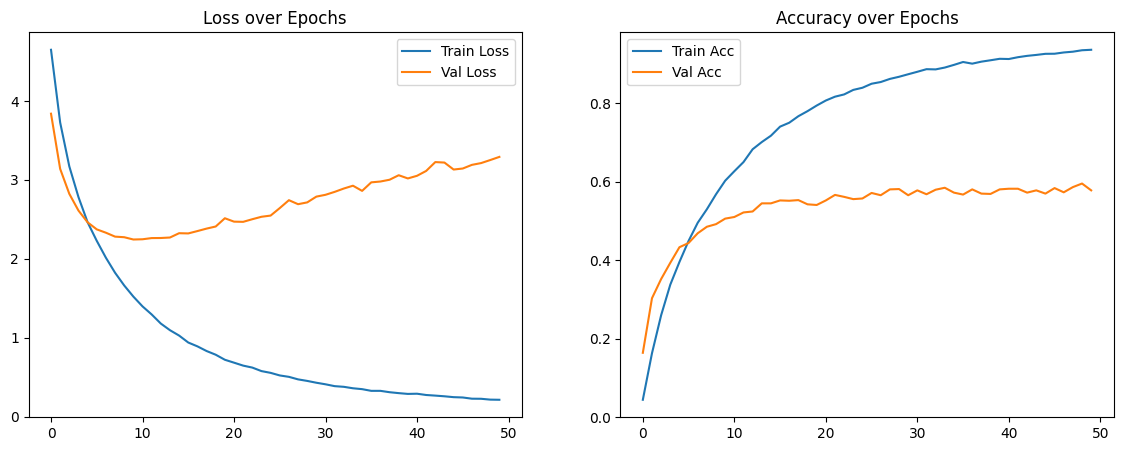

In [17]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [19]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_5aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_5aug:
        images = images.to(DEVICE)
        outputs = model_5aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
report = classification_report(all_labels, all_preds, target_names=le.classes_)
print(report)

# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.38      0.62      0.48         8
  aerodactyl       0.75      0.75      0.75         8
    alakazam       0.54      0.88      0.67         8
       arbok       0.38      0.75      0.50         8
    arcanine       0.67      0.50      0.57         8
    articuno       0.75      0.75      0.75         8
    beedrill       0.80      0.50      0.62         8
  bellsprout       0.60      0.38      0.46         8
   blastoise       1.00      0.62      0.77         8
   bulbasaur       0.60      0.75      0.67         8
  butterfree       0.75      0.75      0.75         8
    caterpie       0.56      0.62      0.59         8
     chansey       0.83      0.62      0.71         8
   charizard       0.88      0.88      0.88         8
  charmander       0.33      0.38      0.35         8
  charmeleon       0.40      0.25      0.31         8
    clefable       0.88      0.88      0.8

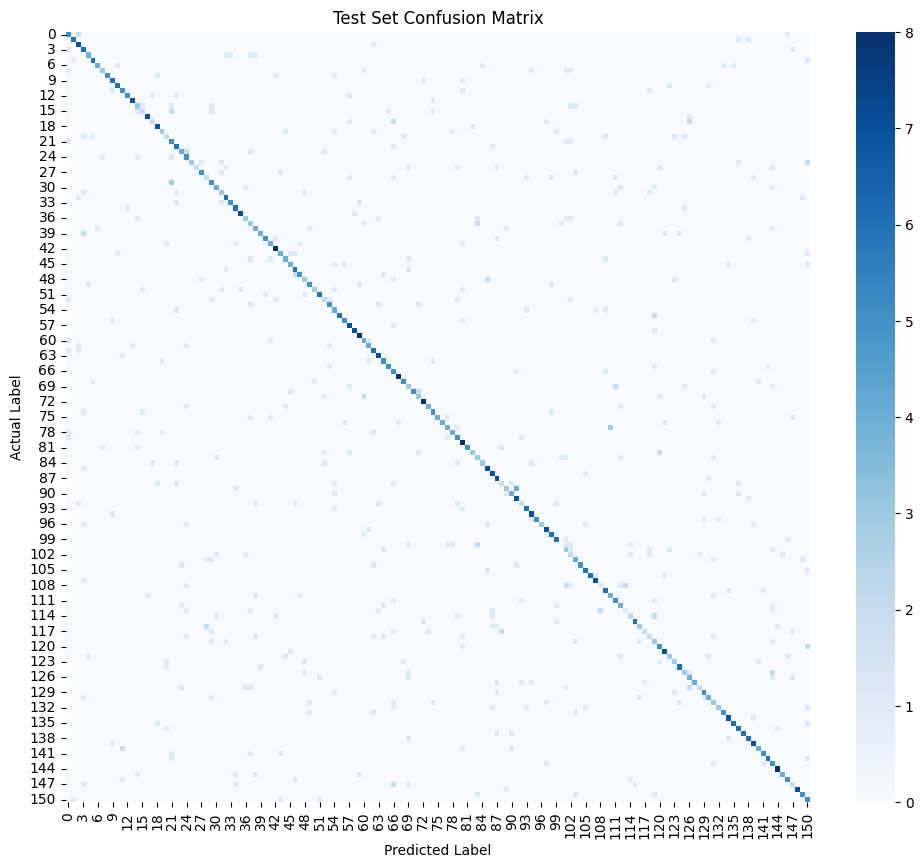

In [21]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Run with cleaned images (10 aug)

In [22]:
# 1. Load the .npy files
x_train_10aug = np.load('./Pokemon/X_train_10aug.npy')
y_train_10aug = np.load('./Pokemon/y_train_10aug.npy')

x_val_10aug = np.load('./Pokemon/X_val_10aug.npy')
y_val_10aug = np.load('./Pokemon/y_val_10aug.npy')

x_test_10aug = np.load('./Pokemon/X_test_10aug.npy')
y_test_10aug = np.load('./Pokemon/y_test_10aug.npy')

le = LabelEncoder()
y_train_idx_10aug = le.fit_transform(y_train_10aug)  
y_val_idx_10aug   = le.transform(y_val_10aug)        
y_test_idx_10aug  = le.transform(y_test_10aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [23]:
train_loader_10aug = DataLoader(NumpyDataset(x_train_10aug, y_train_idx_10aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_10aug   = DataLoader(NumpyDataset(x_val_10aug, y_val_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_10aug  = DataLoader(NumpyDataset(x_test_10aug, y_test_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [24]:
# Initialize Model
model_10aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_10aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_10aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_10aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_10aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_10aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_10aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_10aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_10aug),
        "train_acc":  train_correct / len(x_train_10aug),
        "val_loss":   val_loss / len(x_val_10aug),
        "val_acc":    val_correct / len(x_val_10aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 4.5368 Acc: 0.0529 | Val Loss: 3.4644 Acc: 0.2152
Epoch 02/50 | Train Loss: 3.5945 Acc: 0.1896 | Val Loss: 2.8220 Acc: 0.3460
Epoch 03/50 | Train Loss: 3.0931 Acc: 0.2852 | Val Loss: 2.4846 Acc: 0.4106
Epoch 04/50 | Train Loss: 2.7233 Acc: 0.3587 | Val Loss: 2.3002 Acc: 0.4578
Epoch 05/50 | Train Loss: 2.4676 Acc: 0.4091 | Val Loss: 2.1578 Acc: 0.4843
Epoch 06/50 | Train Loss: 2.2467 Acc: 0.4565 | Val Loss: 2.1295 Acc: 0.5075
Epoch 07/50 | Train Loss: 2.0589 Acc: 0.4965 | Val Loss: 2.0493 Acc: 0.5265
Epoch 08/50 | Train Loss: 1.8928 Acc: 0.5284 | Val Loss: 2.0240 Acc: 0.5356
Epoch 09/50 | Train Loss: 1.7617 Acc: 0.5575 | Val Loss: 2.0225 Acc: 0.5538
Epoch 10/50 | Train Loss: 1.6352 Acc: 0.5843 | Val Loss: 1.9885 Acc: 0.5695
Epoch 11/50 | Train Loss: 1.5307 Acc: 0.6131 | Val Loss: 2.0024 Acc: 0.5762
Epoch 12/50 | Train Loss: 1.4463 Acc: 0.6297 | Val Loss: 1.9353 Acc: 0.5795
Epoch 13/50 | Train Loss: 1.3587 Acc: 0.6510 | Val Loss: 1

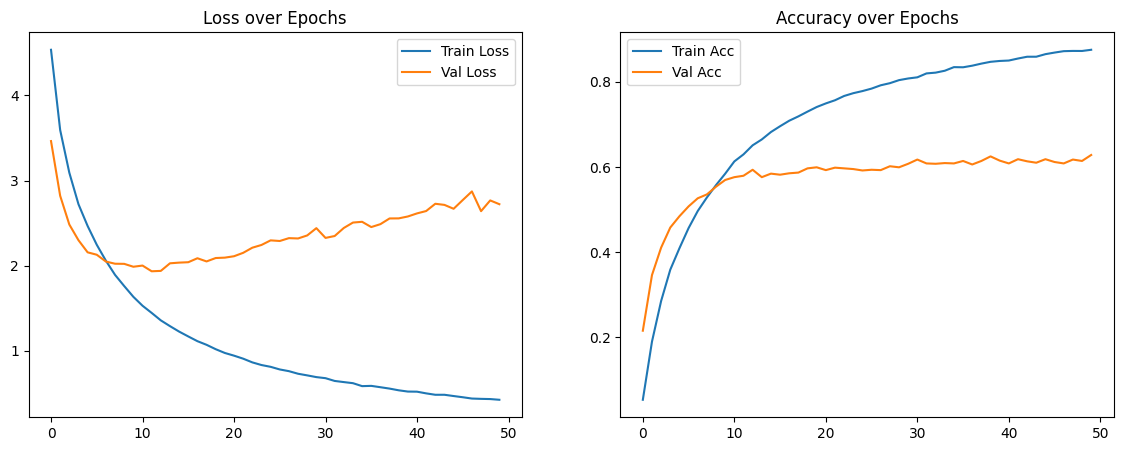

In [25]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [26]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_10aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_10aug:
        images = images.to(DEVICE)
        outputs = model_10aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
report = classification_report(all_labels, all_preds, target_names=le.classes_)
print(report)

# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.45      0.62      0.53         8
  aerodactyl       0.64      0.88      0.74         8
    alakazam       0.54      0.88      0.67         8
       arbok       0.67      0.75      0.71         8
    arcanine       0.67      0.50      0.57         8
    articuno       0.44      0.88      0.58         8
    beedrill       0.83      0.62      0.71         8
  bellsprout       0.80      0.50      0.62         8
   blastoise       0.57      0.50      0.53         8
   bulbasaur       0.60      0.75      0.67         8
  butterfree       0.86      0.75      0.80         8
    caterpie       0.40      0.50      0.44         8
     chansey       0.71      0.62      0.67         8
   charizard       0.88      0.88      0.88         8
  charmander       0.30      0.75      0.43         8
  charmeleon       0.50      0.38      0.43         8
    clefable       0.75      0.75      0.7

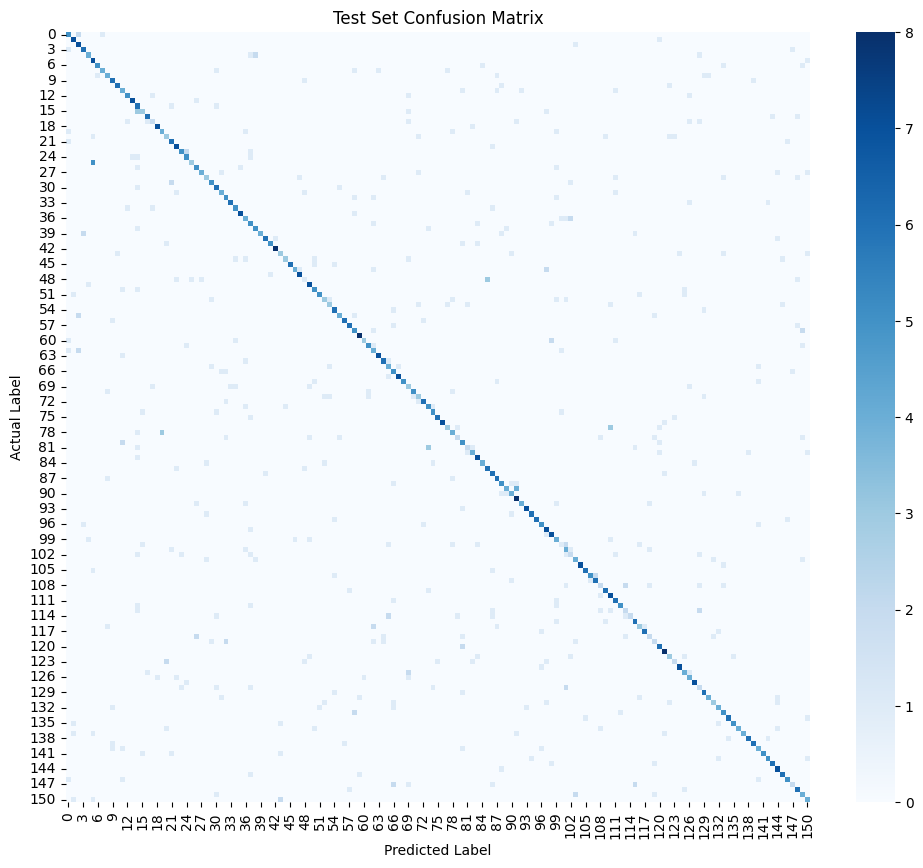

In [27]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()